In [1]:
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
import matplotlib.pyplot as plt



seed = 20
torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
class_150_missing = torch.load("classification_sampling_results_dual_150_2816samples_sigmiainit1_temp_0.5.pt")
class_300_missing = torch.load("classification_sampling_results_dual_300_2816samples_sigmiainit0.5_temp_0.5.pt")
class_50_missing = torch.load("classification_sampling_results_dual_50_2816samples_sigmiainit2_temp_0.5.pt")
class_100_missing = torch.load("classification_sampling_results_dual_100_2816samples_sigmiainit1_temp_0.5.pt")
class_gt = torch.load("classification_sampling_results_gt.pt")

errors_adaptive = [class_300_missing['errors_adaptive'],
                class_150_missing['errors_adaptive'],
                class_100_missing['errors_adaptive'], 
              class_50_missing['errors_adaptive'],
                  ]

errors_classical = [ class_300_missing['errors_classical'], 
                    class_150_missing['errors_classical'], 
                    class_100_missing['errors_classical'], 
          class_50_missing['errors_classical']]



num_meas = [300, 150, 100, 50]

In [3]:
errors_adaptive, errors_classical

([0.012073863636363636,
  0.018821022727272728,
  0.07634943181818182,
  0.3448153409090909],
 [0.010298295454545454, 0.041193181818181816, 0.09765625, 0.46129261363636365])

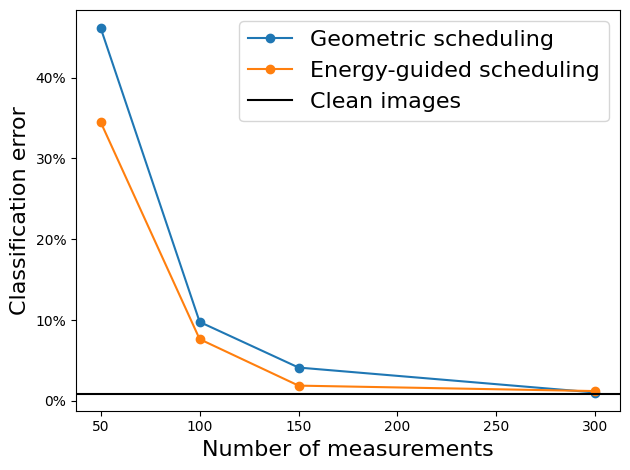

In [12]:

# !module load texlive/2023

# # 1. Configure Matplotlib to use LaTeX for all text
# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "serif",  # Often preferred for LaTeX documents
#     "font.serif": ["Computer Modern Roman"], # Ensure CM font is used
# })

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick  # Import the ticker module

plt.figure()
plt.plot(num_meas, errors_classical, 'o-', label = 'Geometric scheduling')
plt.plot(num_meas, errors_adaptive,'o-', label = 'Energy-guided scheduling')
plt.axhline(y = 0.00817, color = 'k', linestyle='-', label = 'Clean images')

# Change y-axis labeling to % 
# PercentFormatter(1.0) means that a value of 1.0 represents 100%
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

plt.ylabel('Classification error', fontsize = 16)
plt.xlabel('Number of measurements', fontsize = 16)
plt.legend(fontsize = 16)
plt.tight_layout()
# plt.show()
plt.savefig('classification_error.pdf')